**Author**: Felipe Matheus  
**Start Date**: 23/07/2026  
**End Date**: 24/07/2026  
**Related Links**:

- Results so far: https://docs.google.com/spreadsheets/d/1OnIWY_bKxgdGU3trECDTL971WfXFPWgbW-dQzgP6KhI/edit?gid=0#gid=0
- Dataset used: https://drive.google.com/drive/u/0/folders/1VsU-taxtwfmDLUu5Z4JmdgXSoxUoB8FI

**Objective**

Build an uncertainty-aware probabilistic predictor of conductivity (IACS) after the **annealing** process, using AutoGluon. The output of every prediction is a Gaussian-like predictive distribution $\mathcal{N}(\hat\mu, \hat\sigma^2)$ where the variance is decomposed into epistemic and aleatoric components.

**Pipeline**

1. Setup and global configuration.
2. Load + preprocess data.
3. Train **Model A** (mean predictor with internal K-fold bagging).
4. Extract OOF predictions per base learner.
5. Recover ensemble weights via NNLS; compute weighted $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$.
6. Build aleatoric targets $\tilde r^2 = \max(r^2_{\text{OOF}} - \hat\sigma^2_{\text{epist}}, 0)$.
7. Train **Model B** on $\log(\tilde r^2 + \epsilon)$.
8. Calibration diagnostics and scalar recalibration.

# 1. Setup

In [1]:
import os
import sys
import pickle

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from scipy.stats import norm
from autogluon.tabular import TabularPredictor


module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.processing.Processing import Processing
from src.feature_engineering.FeatureEngineering import FeatureEngineering
from src.modeling.Modeling import Modeling
from src.metrics.Evaluation import Evaluation
from src.DataLoader import LoaderHelper

from config.Variables import Variables

%load_ext autoreload
%autoreload 2

c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Helper instances reused across the notebook.
proc = Processing()
feng = FeatureEngineering()
modl = Modeling()
evla = Evaluation()
varv = Variables()
load = LoaderHelper()


## 1.1 Global configuration

All knobs that may change between surrogates / processes / experiments live here. Other notebooks for other surrogates only need to edit this cell.

In [3]:
# ---- Experiment settings ----
TAG = "only-essays-v2-best-quality"
SCHEMA_DATE = "230726"

# ---- Paths ----
FILE_NAME = "dataset_annealing_iacs.csv"
FILE_NAME_SCHEMA_DATA = "schema_annealing_essays_{}.csv".format(SCHEMA_DATE)
# FILE_NAME_VALIDATION_DATA = "Experimental Results Annealing V2 - CompiledResults.csv"

PROCESS = "annealing_elongation"

# All artifacts of THIS run (predictors included) live under the TAG folder,
# so different experiments never overwrite each other's models.
EXPERIMENT_DIR = os.path.join(varv.PATHS.models, PROCESS, TAG)
os.makedirs(EXPERIMENT_DIR, exist_ok=True)

# ---- Dataset schema ----
TARGET = "elongation_final"
FEATURES = ["initial_diameter", "tensile_strength", "purity", "elongation", "temperature", "time"]
WEIGHT_ON_ESSAY_ROWS = 1

# ---- AutoGluon training knobs (Model A) ----
PRESETS_A = "best_quality"     # 'best_quality' for final runs only or medium_quality
NUM_BAG_FOLDS_A = 5               # K-fold bagging produces OOF preds
NUM_BAG_SETS_A = 1
NUM_STACK_LEVELS_A = 0            # no multi-level stacking; keep simple
TIME_LIMIT_A = 120

# ---- AutoGluon training knobs (Model B) ----
PRESETS_B = "medium_quality"
NUM_BAG_FOLDS_B = 5
NUM_STACK_LEVELS_B = 0
TIME_LIMIT_B = 60

# ---- Uncertainty pipeline knobs ----
USE_WEIGHTED_VARIANCE = True      # False = uniform mean/var (sanity check)
VARIANCE_FLOOR_FRAC = 0.01        # floor of sigma2_aleat as fraction of Var(y), in case of predictions as "100% sure" it still adds  small variance
CALIBRATION_ALPHAS = (0.5, 0.8, 0.9, 0.95)
RECALIBRATION_TARGET_ALPHA = 0.9

# ---- AGL x H2O comparison ----
USE_SHARED_FOLDS = False           # same fold_id column on both engines
FOLD_SEED = 42

# ---- Physical constraints (inference-time) ----
Y_MAX = 105.0                     # physical ceiling for %IACS


# 2. Data

## 2.1 Schema data

In [5]:
df, df_val = proc.process_annealing_elongation(
    features=FEATURES,
    target=TARGET,
    df_schema=pd.read_csv(os.path.join(varv.PATHS.data_raw, FILE_NAME_SCHEMA_DATA))
)

In [6]:
df

,initial_diameter,tensile_strength,purity,elongation,temperature,time,elongation_final
0,2.160000,391.690000,99.9000,4.90,573.0,30.0,48.60
1,2.182333,387.595254,99.9000,6.02,573.0,30.0,56.21
2,1.200000,431.580000,99.9000,0.94,523.0,30.0,20.15
3,1.200000,431.580000,99.9000,0.94,523.0,60.0,22.04
4,1.200000,431.580000,99.9000,0.94,523.0,90.0,24.62
5,1.200000,431.580000,99.9000,0.94,573.0,30.0,24.72
6,1.200000,431.580000,99.9000,0.94,573.0,60.0,27.43
7,1.200000,431.580000,99.9000,0.94,573.0,90.0,25.24
8,1.200000,431.580000,99.9000,0.94,623.0,30.0,27.06
9,1.200000,431.580000,99.9000,0.94,623.0,60.0,26.17


## 2.2 Validation data

In [ ]:
# # ---- Validation data ----
# df_val = proc.load_validation_data_chimie_paris(
#     path=os.path.join(varv.PATHS.data_processed, FILE_NAME_VALIDATION_DATA)
# )


In [7]:
df_val

,initial_diameter,tensile_strength,purity,elongation,temperature,time,elongation_final
9,1.20,431.58,99.9000,0.94,623.0,60.0,26.17
25,2.00,376.08,99.9558,5.33,573.0,30.0,8.55
8,1.20,431.58,99.9000,0.94,623.0,30.0,27.06
21,1.20,335.21,99.9800,1.61,523.0,30.0,51.01
0,2.16,391.69,99.9000,4.90,573.0,30.0,48.60
12,1.20,397.09,99.9000,2.36,573.0,30.0,44.18
17,1.20,397.09,99.9000,2.36,523.0,90.0,42.28
22,1.20,335.21,99.9800,1.61,523.0,60.0,49.42


# 3. Train Model A — Mean Predictor with Bagging

Model A is an AutoGluon ensemble trained with $K$-fold bagging internally. Bagging is non-optional: without it we cannot extract OOF predictions, which are required for honest residuals and for the epistemic-variance estimate.

In [13]:
df.head(10)

,initial_diameter,tensile_strength,purity,elongation,temperature,time,elongation_final
0,2.160000,391.690000,99.9,4.90,573.0,30.0,48.60
1,2.182333,387.595254,99.9,6.02,573.0,30.0,56.21
2,1.200000,431.580000,99.9,0.94,523.0,30.0,20.15
3,1.200000,431.580000,99.9,0.94,523.0,60.0,22.04
4,1.200000,431.580000,99.9,0.94,523.0,90.0,24.62
5,1.200000,431.580000,99.9,0.94,573.0,30.0,24.72
6,1.200000,431.580000,99.9,0.94,573.0,60.0,27.43
7,1.200000,431.580000,99.9,0.94,573.0,90.0,25.24
8,1.200000,431.580000,99.9,0.94,623.0,30.0,27.06
9,1.200000,431.580000,99.9,0.94,623.0,60.0,26.17


In [8]:
df.head(10)

,initial_diameter,tensile_strength,purity,elongation,temperature,time,elongation_final,is_essay,weight_col
0,2.160000,391.690000,99.9,4.90,573.0,30.0,48.60,True,1.0
1,2.182333,387.595254,99.9,6.02,573.0,30.0,56.21,True,1.0
2,1.200000,431.580000,99.9,0.94,523.0,30.0,20.15,True,1.0
3,1.200000,431.580000,99.9,0.94,523.0,60.0,22.04,True,1.0
4,1.200000,431.580000,99.9,0.94,523.0,90.0,24.62,True,1.0
5,1.200000,431.580000,99.9,0.94,573.0,30.0,24.72,True,1.0
6,1.200000,431.580000,99.9,0.94,573.0,60.0,27.43,True,1.0
7,1.200000,431.580000,99.9,0.94,573.0,90.0,25.24,True,1.0
8,1.200000,431.580000,99.9,0.94,623.0,30.0,27.06,True,1.0
9,1.200000,431.580000,99.9,0.94,623.0,60.0,26.17,True,1.0


In [12]:
predictor_a = modl.fit_model_a(
    df=df,
    target=TARGET,
    features=FEATURES,
    path=os.path.join(EXPERIMENT_DIR, "model_a"),
    presets=PRESETS_A,
    num_bag_folds=NUM_BAG_FOLDS_A,
    num_bag_sets=NUM_BAG_SETS_A,
    num_stack_levels=NUM_STACK_LEVELS_A,
    time_limit=TIME_LIMIT_A,
    # groups="fold_id" if USE_SHARED_FOLDS else None,
    # sample_weight="weight_col",
)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       7.79 GB / 31.57 GB (24.7%)
Disk Space Avail:   739.04 GB / 932.08 GB (79.3%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Stack configuration (auto_stack=True): num_stack_levels=0, num_bag_folds=5, num_bag_sets=1
Beginning AutoGluon training ... Time limit = 120s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_elongation\only-essays-v2-best-quality\model_a"
Train Data Rows:    28
Train Data Columns: 6
Label Column:       elongation_final
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-v

In [14]:
# Inspect the leaderboard. Last row is WeightedEnsemble_L2; the rest are
# base learners that feed into it.
predictor_a.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-7.702562,root_mean_squared_error,0.021977,7.414273,0.000000,0.010575,2,True,17
1,NeuralNetTorch_r79_BAG_L1,-7.702562,root_mean_squared_error,0.021977,7.403698,0.021977,7.403698,1,True,11
2,NeuralNetTorch_r22_BAG_L1,-7.854392,root_mean_squared_error,0.034128,9.168691,0.034128,9.168691,1,True,16
3,NeuralNetTorch_BAG_L1,-8.432435,root_mean_squared_error,0.024407,7.840160,0.024407,7.840160,1,True,8
4,LightGBMLarge_BAG_L1,-9.129597,root_mean_squared_error,0.003010,1.401642,0.003010,1.401642,1,True,9
5,XGBoost_BAG_L1,-10.600081,root_mean_squared_error,0.009315,0.861171,0.009315,0.861171,1,True,7
6,CatBoost_BAG_L1,-10.782491,root_mean_squared_error,0.006490,2.221632,0.006490,2.221632,1,True,4
7,CatBoost_r9_BAG_L1,-10.798098,root_mean_squared_error,0.006478,8.067231,0.006478,8.067231,1,True,14
8,CatBoost_r177_BAG_L1,-10.813952,root_mean_squared_error,0.014233,3.326710,0.014233,3.326710,1,True,10
9,ExtraTreesMSE_BAG_L1,-11.605972,root_mean_squared_error,0.060063,0.454811,0.060063,0.454811,1,True,5


## 3.1 H2O AutoML Comparison

Quick H2O AutoML run with the same time budget and cross-validation folds as Model A, to benchmark AutoGluon's OOF RMSE against H2O's leader CV RMSE.

In [ ]:
aml_h2o = modl.fit_h2o_automl(
    df= df,
    target= TARGET,
    features= FEATURES,
    weight_on_essay_rows= WEIGHT_ON_ESSAY_ROWS,
    num_bag_folds= NUM_BAG_FOLDS_A,
    use_shared_folds= USE_SHARED_FOLDS,
    time_limit= TIME_LIMIT_A
)

Checking whether there is an H2O instance running at http://localhost:54321. connected.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,31 mins 47 secs
H2O_cluster_timezone:,Europe/Paris
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,4 months and 17 days
H2O_cluster_name:,H2O_from_python_fmfoa_2r65wi
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.128 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |█
12:37:11.745: AutoML: XGBoost is not available; skipping it.
12:37:11.831: _min_rows param, The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 28.0.

██████████████████████████████████████████████████████████████| (done) 100%
model_id                                          rmse      mse      mae     rmsle    mean_residual_deviance
GBM_grid_1_AutoML_3_20260729_123711_model_89   9.19613  84.5687  5.21143  0.331241                   84.5687
GBM_grid_1_AutoML_3_20260729_123711_model_183  9.34437  87.3173  5.25937  0.332741                   87.3173
GBM_grid_1_AutoML_3_20260729_123711_model_406  9.4402   89.1173  5.31971  0.335676                   89.1173
GBM_grid_1_AutoML_3_20260729_123711_model_30   9.47466  89.7693  5.32579  0.333073                   89.7693
GBM_grid_1_AutoML_3_20260729_123711_model_78   9.4

In [20]:
aml_h2o.leaderboard.head(10)

model_id,rmse,mse,mae,rmsle,mean_residual_deviance
GBM_grid_1_AutoML_3_20260729_123711_model_89,9.19613,84.5687,5.21143,0.331241,84.5687
GBM_grid_1_AutoML_3_20260729_123711_model_183,9.34437,87.3173,5.25937,0.332741,87.3173
GBM_grid_1_AutoML_3_20260729_123711_model_406,9.4402,89.1173,5.31971,0.335676,89.1173
GBM_grid_1_AutoML_3_20260729_123711_model_30,9.47466,89.7693,5.32579,0.333073,89.7693
GBM_grid_1_AutoML_3_20260729_123711_model_78,9.48566,89.9777,5.10773,0.336748,89.9777
GBM_grid_1_AutoML_3_20260729_123711_model_117,9.49783,90.2088,5.13096,0.33653,90.2088
GBM_grid_1_AutoML_3_20260729_123711_model_536,9.51728,90.5787,5.32798,0.334654,90.5787
GBM_grid_1_AutoML_3_20260729_123711_model_157,9.52775,90.7779,5.12144,0.33689,90.7779
GBM_grid_1_AutoML_3_20260729_123711_model_69,9.55274,91.2548,5.20455,0.336689,91.2548
GBM_grid_1_AutoML_3_20260729_123711_model_60,9.56624,91.5129,5.39127,0.338869,91.5129


NOTE: the previous cell here compared AutoGluon's `score_val` against
H2O's xval RMSE.

That comparison is incoherent when sample weights are
active: H2O's xval RMSE is WEIGHTED by weights_column, while AutoGluon's
score_val is UNWEIGHTED unless weight_evaluation=True.

The fair, like-for-like comparison (unweighted metrics on OOF predictions of both
engines, same y_true, same folds when USE_SHARED_FOLDS) is done in
Section 10 ("OOF metrics: AutoGluon vs H2O").


# 4. OOF Predictions and Ensemble Weights

Three things are needed before we can compute the epistemic variance:

1. The OOF predictions of the **final ensemble** (one value per row of the train set).
2. The OOF predictions of **each base learner** (one matrix `M × N`).
3. The **weights** that the WeightedEnsemble assigns to each base learner — recovered via NNLS from the OOF matrix and the ensemble OOF vector. The internal AutoGluon API for weights is not stable across versions; NNLS gives a robust route.

In [21]:
# OOF mean predictions of the final ensemble.
mu_oof = predictor_a.predict_oof()                  # pd.Series, index == df.index
residuals_oof = np.abs(df[TARGET] - mu_oof)
print(f"mu_oof: shape={mu_oof.shape}  any NaN? {mu_oof.isna().any()}")

mu_oof: shape=(28,)  any NaN? False


## 4.1 fast check on big residuals

In [29]:
df_verification = pd.concat(
    [df[FEATURES + [TARGET]],
     mu_oof.rename(f"{TARGET}_pred"),
     residuals_oof.rename("residual")], axis=1
)

df_verification.sort_values(by="residual")
# 

,initial_diameter,tensile_strength,purity,elongation,temperature,time,elongation_final,elongation_final_pred,residual
10,1.200000,431.580000,99.9000,0.94,623.0,90.0,27.39,27.341410,0.048590
8,1.200000,431.580000,99.9000,0.94,623.0,30.0,27.06,26.625267,0.434733
22,1.200000,335.210000,99.9800,1.61,523.0,60.0,49.42,48.957298,0.462702
0,2.160000,391.690000,99.9000,4.90,573.0,30.0,48.60,48.106594,0.493406
20,1.200000,335.210000,99.9800,1.61,573.0,90.0,46.64,46.116390,0.523610
3,1.200000,431.580000,99.9000,0.94,523.0,60.0,22.04,22.677095,0.637095
15,1.200000,397.090000,99.9000,2.36,523.0,30.0,38.77,39.512321,0.742321
5,1.200000,431.580000,99.9000,0.94,573.0,30.0,24.72,25.527365,0.807365
17,1.200000,397.090000,99.9000,2.36,523.0,90.0,42.28,41.471878,0.808122
11,1.200000,412.640000,99.9000,3.25,573.0,30.0,37.28,38.235828,0.955828


## 4.2 Recovering weights 

In [26]:
# OOF matrix per base learner (excludes WeightedEnsemble itself).
oof_matrix, base_model_names = modl.collect_oof_base_learners(predictor_a)
print(f"oof_matrix shape: {oof_matrix.shape}  (M base learners, N rows)")
print("Base learners:", base_model_names)

oof_matrix shape: (16, 28)  (M base learners, N rows)
Base learners: ['LightGBMXT_BAG_L1', 'LightGBM_BAG_L1', 'RandomForestMSE_BAG_L1', 'CatBoost_BAG_L1', 'ExtraTreesMSE_BAG_L1', 'NeuralNetFastAI_BAG_L1', 'XGBoost_BAG_L1', 'NeuralNetTorch_BAG_L1', 'LightGBMLarge_BAG_L1', 'CatBoost_r177_BAG_L1', 'NeuralNetTorch_r79_BAG_L1', 'LightGBM_r131_BAG_L1', 'NeuralNetFastAI_r191_BAG_L1', 'CatBoost_r9_BAG_L1', 'LightGBM_r96_BAG_L1', 'NeuralNetTorch_r22_BAG_L1']


In [35]:
# Recover ensemble weights by solving (oof_matrix.T @ w = mu_oof) with w >= 0.
weights, is_recovery_ok, max_diff = modl.recover_ensemble_weights(
    oof_matrix=oof_matrix,
    mu_oof_ensemble=mu_oof.values,
)

print(f"Recovery max diff: {max_diff:.6f}  ({'OK' if is_recovery_ok else 'FALLBACK'})")
print("\nNon-zero weights:")
for name, w in zip(base_model_names, weights):
    if w > 1e-4:
        print(f"  {name:30s}  {w:.4f}")

Recovery max diff: 0.000000  (OK)

Non-zero weights:
  NeuralNetTorch_r79_BAG_L1       1.0000


# 5. Compute $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$

Following the law of total variance, the epistemic component is the spread of the predictions across base learners, weighted by the ensemble weights. The `USE_WEIGHTED_VARIANCE` flag toggles between weighted (the project default) and uniform statistics — the latter is useful as a robustness check, since it does not rely on the NNLS recovery.

In [36]:
mu_recomputed, sigma2_epist_oof = modl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=USE_WEIGHTED_VARIANCE,
)

mu_diffs = np.abs(mu_recomputed - mu_oof)
mu_diffs.describe()
# print("sigma2_epist_oof stats:")
# print(f"  mean   = {sigma2_epist_oof.mean():.4f}")
# print(f"  median = {np.median(sigma2_epist_oof):.4f}")
# print(f"  max    = {sigma2_epist_oof.max():.4f}")

count    2.800000e+01
mean     3.425831e-15
std      3.130534e-15
min      0.000000e+00
25%      0.000000e+00
50%      3.552714e-15
75%      7.105427e-15
max      7.105427e-15
Name: elongation_final, dtype: float64

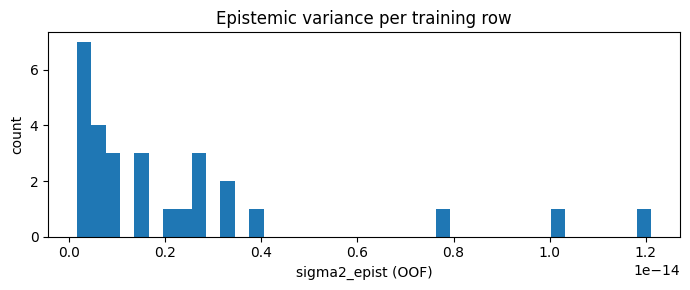

In [37]:
plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

## Assesment comparing with lin

In [38]:
mu_recomputed_lin, sigma2_epist_oof_lin = modl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=False,
)

mu_diffs_lin = np.abs(mu_recomputed_lin - mu_oof)
mu_diffs_lin.describe()
# print("sigma2_epist_oof stats:")
# print(f"  mean   = {sigma2_epist_oof_lin.mean():.4f}")
# print(f"  median = {np.median(sigma2_epist_oof_lin):.4f}")
# print(f"  max    = {sigma2_epist_oof_lin.max():.4f}")

count    28.000000
mean      4.895637
std       4.087761
min       0.177792
25%       1.424877
50%       4.220081
75%       6.514570
max      17.031940
Name: elongation_final, dtype: float64

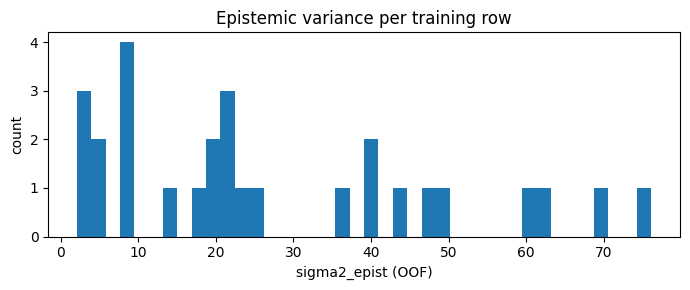

In [39]:
plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof_lin, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

## Section 5 Conclusion
When number of lines is at least > 40 

Linear shows way more errors between the recomputed values. Weighted one is corrected.

# 6. Build Aleatoric Targets $\tilde r^2$

Each training row gets a noisy point-estimate of the aleatoric variance:

$$\tilde r_i^2 = \max\!\left((y_i - \hat\mu^{\text{OOF}}(\mathbf{x}_i))^2 - \hat\sigma^2_{\text{epist}}(\mathbf{x}_i),\;0\right).$$

Subtracting the epistemic component avoids double-counting it. Truncation at zero handles rows where the ensemble disagreement exceeds the squared residual.

In [40]:
r_tilde_sq, residuals_oof_arr, diag = modl.build_aleatoric_targets(
    y_true=df[TARGET].values,
    mu_oof=mu_oof.values,
    sigma2_epist_oof=sigma2_epist_oof,
)

print("=== Aleatoric target diagnostics ===")
for k, v in diag.items():
    print(f"  {k:20s} = {v}")

=== Aleatoric target diagnostics ===
  n_total              = 28
  n_truncated          = 0
  pct_truncated        = 0.0
  r_tilde_sq_min       = 0.0023610188840472767
  r_tilde_sq_max       = 1322.4299382150384
  r_tilde_sq_mean      = 59.32946028782822
  r_tilde_sq_median    = 4.568980971627912


In [41]:
r_tilde_sq

array([2.43449396e-01, 7.50974625e+01, 5.52128089e+00, 4.05890566e-01,
       2.86796701e+00, 6.51837809e-01, 4.25436950e+01, 8.01794489e+01,
       1.88992756e-01, 1.72418386e+00, 2.36101888e-03, 9.13607930e-01,
       1.81022073e+01, 1.26598213e+01, 2.51820956e+00, 5.51041168e-01,
       1.29431492e+01, 6.53061083e-01, 1.48000169e+01, 7.23119828e+00,
       2.74167193e-01, 5.85759943e+00, 2.14092883e-01, 4.52619652e+00,
       4.61176543e+00, 1.32242994e+03, 2.93003595e+01, 1.42118864e+01])

# 7. Train Model B — Aleatoric Variance Predictor

Model B is trained on $\log(\tilde r^2 + \epsilon)$ to keep the regression target well-conditioned (variances are non-negative and right-skewed). Inference back-transforms via $\exp$.

In [42]:
predictor_b = modl.fit_model_b(
    df=df,
    features=FEATURES,
    r_tilde_sq=r_tilde_sq,
    path=os.path.join(EXPERIMENT_DIR, "model_b"),
    presets=PRESETS_B,
    num_bag_folds=NUM_BAG_FOLDS_B,
    num_stack_levels=NUM_STACK_LEVELS_B,
    time_limit=TIME_LIMIT_B,
)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       3.38 GB / 31.57 GB (10.7%)
Disk Space Avail:   738.03 GB / 932.08 GB (79.2%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 60s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_elongation\only-essays-v2-best-quality\model_b"
Train Data Rows:    28
Train Data Columns: 6
Label Column:       log_r_tilde_sq
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mean, stddev): (7.187226186310301, -6.048238566299351

In [43]:
predictor_b.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-2.606587,root_mean_squared_error,0.089452,9.070178,0.001506,0.007322,2,True,10
1,XGBoost_BAG_L1,-2.648568,root_mean_squared_error,0.013197,1.023438,0.013197,1.023438,1,True,7
2,NeuralNetTorch_BAG_L1,-2.672942,root_mean_squared_error,0.032558,7.513163,0.032558,7.513163,1,True,8
3,CatBoost_BAG_L1,-2.743910,root_mean_squared_error,0.010499,2.265399,0.010499,2.265399,1,True,4
4,LightGBMLarge_BAG_L1,-2.768297,root_mean_squared_error,0.003999,1.402446,0.003999,1.402446,1,True,9
5,NeuralNetFastAI_BAG_L1,-2.806158,root_mean_squared_error,0.063673,11.815242,0.063673,11.815242,1,True,6
6,LightGBMXT_BAG_L1,-2.809715,root_mean_squared_error,0.002999,1.176676,0.002999,1.176676,1,True,1
7,LightGBM_BAG_L1,-2.809715,root_mean_squared_error,0.003976,1.775899,0.003976,1.775899,1,True,2
8,RandomForestMSE_BAG_L1,-2.869398,root_mean_squared_error,0.042191,0.526255,0.042191,0.526255,1,True,3
9,ExtraTreesMSE_BAG_L1,-2.940435,root_mean_squared_error,0.062002,0.514079,0.062002,0.514079,1,True,5


In [50]:
df_verification_b = pd.concat(
    [df_verification,
     pd.Series(sigma2_epist_oof, index=df_verification.index, name="epistemic_error"),
     predictor_b.predict_oof().rename("predict_random_error"),
    ], axis=1
)
df_verification_b

,initial_diameter,tensile_strength,purity,elongation,temperature,time,elongation_final,elongation_final_pred,residual,epistemic_error,predict_random_error
0,2.160000,391.690000,99.9000,4.90,573.0,30.0,48.60,48.106594,0.493406,3.292741e-15,2.039026
1,2.182333,387.595254,99.9000,6.02,573.0,30.0,56.21,47.544121,8.665879,1.525615e-15,1.449515
2,1.200000,431.580000,99.9000,0.94,523.0,30.0,20.15,22.499741,2.349741,2.556926e-15,-0.099547
3,1.200000,431.580000,99.9000,0.94,523.0,60.0,22.04,22.677095,0.637095,2.564068e-15,1.019629
4,1.200000,431.580000,99.9000,0.94,523.0,90.0,24.62,22.926493,1.693507,2.599325e-15,0.162408
5,1.200000,431.580000,99.9000,0.94,573.0,30.0,24.72,25.527365,0.807365,3.950332e-15,1.448632
6,1.200000,431.580000,99.9000,0.94,573.0,60.0,27.43,33.952553,6.522553,2.224554e-16,0.459904
7,1.200000,431.580000,99.9000,0.94,573.0,90.0,25.24,34.194298,8.954298,2.079270e-16,0.339262
8,1.200000,431.580000,99.9000,0.94,623.0,30.0,27.06,26.625267,0.434733,3.226068e-15,0.068427
9,1.200000,431.580000,99.9000,0.94,623.0,60.0,26.17,27.483082,1.313082,2.483776e-15,0.010063


# 8. Calibration Diagnostics

Test whether the central α-intervals produced by the predictive Gaussian actually contain the true $y$ on a fraction $\approx \alpha$ of OOF points.

- $\alpha$ here is the **nominal coverage** of an interval (between 0 and 1).
- Empirical coverage **below** nominal ⇒ overconfident (intervals too narrow).
- Empirical coverage **above** nominal ⇒ underconfident (intervals too wide).
- A scalar correction $\hat\sigma \mapsto c \cdot \hat\sigma$ pulls the worst level to nominal; we fit $c$ at $\alpha = 0.9$.

Real coverage considering sigmas calculated so far

Build the predictive distribution. Not totally OOF cause model b is not generating OOF preds, we assume it's optimistic just a bit too small to be considered.


In [51]:
variance_floor = VARIANCE_FLOOR_FRAC * df[TARGET].var()
sigma2_aleat_oof = modl.predict_aleatoric_variance(
    predictor_b, df[FEATURES], variance_floor=variance_floor,
)

sigma2_total_oof = sigma2_epist_oof + sigma2_aleat_oof
sigma_total_oof = np.sqrt(sigma2_total_oof)

y_true = df[TARGET].values
cal_before = modl.calibration_table(
    mu=mu_oof.values, sigma=sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("=== Calibration BEFORE recalibration ===")
cal_before

=== Calibration BEFORE recalibration ===


,alpha,empirical_coverage,gap
0,0.50,0.321429,-0.178571
1,0.80,0.500000,-0.300000
2,0.90,0.678571,-0.221429
3,0.95,0.750000,-0.200000


Fit a scalar recalibration factor to pull coverage using α=0.9 as nominal reference


In [52]:
c_opt = modl.fit_recalibration_scalar(
    mu=mu_oof.values,
    sigma=sigma_total_oof,
    y_true=y_true,
    target_alpha=RECALIBRATION_TARGET_ALPHA,
)
print(f"Recalibration scalar c = {c_opt:.4f}")

cal_after = modl.calibration_table(
    mu=mu_oof.values, sigma=c_opt * sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("\n=== Calibration AFTER recalibration ===")
cal_after

Recalibration scalar c = 1.8197

=== Calibration AFTER recalibration ===


,alpha,empirical_coverage,gap
0,0.50,0.500000,0.000000
1,0.80,0.785714,-0.014286
2,0.90,0.892857,-0.007143
3,0.95,0.928571,-0.021429


# 8.1 Validation Set Evaluation

Evaluate the freshly trained pair (A + B, with the recalibration $c$) on a
validation DataFrame.

`modl.predict_target` is target-agnostic: it accepts a DataFrame **or a dict**
and any AutoGluon predictor (IACS, UTS, Model B...), inferring the features
from the predictor when not given.

In [53]:
c_opt
weights

array([0.00000000e+00, 5.21513070e-18, 0.00000000e+00, 1.54511084e-17,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 4.06999944e-17,
       1.94187116e-17, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00])

In [54]:
len(base_model_names)
len(weights)

16

In [55]:
# ---- Validation set: df_schema (illustrative; in-sample, see caveat) ----
# df_val = df_schema.copy()

# Full calibrated predictive distribution on the validation set.
preds_val = modl.predict_with_uncertainty(
    X=df.copy(), # df_schema.copy()
    predictor_a=predictor_a,
    predictor_b=predictor_b,
    weights=weights,
    model_names=base_model_names,
    features=FEATURES,
    variance_floor=variance_floor,
    recalibration_c=c_opt,
    use_weights=USE_WEIGHTED_VARIANCE,
    y_max=Y_MAX,
)

val_metrics = evla.metrics_on_dataframe(
    df=df.copy(), #df_schema.copy()
    target=TARGET,
    mu=preds_val["mu"].to_numpy(),
    sigma=preds_val["sigma_total"].to_numpy(),
    alphas=CALIBRATION_ALPHAS,
)
print("=== Validation metrics (df_schema) ===")
print({k: round(v, 4) for k, v in val_metrics.items() if k != "coverage"})
print("coverage:", {a: round(c, 3) for a, c in val_metrics["coverage"].items()})

=== Validation metrics (df_schema) ===
{'rmse': 6.3007, 'mae': 2.9975, 'mape': 17.8195, 'r2': 0.774}
coverage: {0.5: 0.571, 0.8: 0.964, 0.9: 0.964, 0.95: 0.964}


In [56]:
# # ---- Target-agnostic point prediction from a plain dict ----
# single = modl.predict_target(
#     predictor_a,
#     {"initial_diameter": 1.5, "purity": 99.9, "iacs": 88.26, "temperature": 623.0, "time": 60.0},
# )
# print(f"Predicted {TARGET}: {single[0]:.3f}")

# 9. Inference Example

Use the packaged `predict_with_uncertainty` to apply both models to new rows and return a full predictive distribution. The `recalibration_c` argument scales $\hat\sigma$ to match the calibration above.

In [57]:
df.head(5)

,initial_diameter,tensile_strength,purity,elongation,temperature,time,elongation_final
0,2.160000,391.690000,99.9,4.90,573.0,30.0,48.60
1,2.182333,387.595254,99.9,6.02,573.0,30.0,56.21
2,1.200000,431.580000,99.9,0.94,523.0,30.0,20.15
3,1.200000,431.580000,99.9,0.94,523.0,60.0,22.04
4,1.200000,431.580000,99.9,0.94,523.0,90.0,24.62


In [58]:
# Fit the OOD reference on the training inputs (stored in artifacts later).
ood_ref = modl.fit_ood_reference(df, features=FEATURES)

preds = modl.predict_with_uncertainty(
    X=df.head(5),
    predictor_a=predictor_a,
    predictor_b=predictor_b,
    weights=weights,
    model_names=base_model_names,
    features=FEATURES,
    variance_floor=variance_floor,
    recalibration_c=c_opt,
    use_weights=USE_WEIGHTED_VARIANCE,
    y_max=Y_MAX,          # physical ceiling -> mu_trunc / sigma_trunc / p_above_max
    ood_ref=ood_ref,      # inputs outside training cloud get inflated sigma
)
preds


,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total,leader_model_prediction,ood_multiplier,mu_trunc,sigma_trunc,p_above_max
0,46.829376,7.467556e-16,2.329173,7.712305,2.777104,46.829376,1.0,46.829376,2.777104,0.0
1,53.198494,2.071282e-15,9.680628,32.054280,5.661650,53.198494,1.0,53.198494,5.661650,0.0
2,23.529531,2.569829e-15,2.142878,7.095450,2.663729,23.529531,1.0,23.529531,2.663729,0.0
3,24.352390,2.126354e-15,1.821305,6.030665,2.455741,24.352390,1.0,24.352390,2.455741,0.0
4,25.650723,1.573883e-15,2.101025,6.956868,2.637588,25.650723,1.0,25.650723,2.637588,0.0


# 10. Persist Artifacts

Save everything that the downstream stages (controller, propagation) will need.

In [59]:
# ---- Experiment artifacts (everything under EXPERIMENT_DIR / TAG) ----
artifacts_path = os.path.join(EXPERIMENT_DIR, "artifacts.pkl")

artifacts = {
    "features": FEATURES,
    "target": TARGET,
    "base_model_names": base_model_names,
    "weights": weights,
    "variance_floor": variance_floor,
    "recalibration_c": c_opt,
    "use_weighted_variance": USE_WEIGHTED_VARIANCE,
    "calibration_before": cal_before,
    "calibration_after": cal_after,
    "y_max": Y_MAX,
    "ood_ref": ood_ref,
}
with open(artifacts_path, "wb") as f:
    pickle.dump(artifacts, f)

print(f"Saved to: {artifacts_path}")


Saved to: ../../models/annealing_elongation\only-essays-v2-best-quality\artifacts.pkl


In [60]:
# ---- Save global configuration (1.1) as YAML for this experiment (TAG) ----
global_config = {
    "TAG": TAG,
    "SCHEMA_DATE": SCHEMA_DATE,
    "varv.PATHS.data_raw": varv.PATHS.data_raw,
    "varv.PATHS.models": varv.PATHS.models,
    "FILE_NAME": FILE_NAME,
    "FILE_NAME_SCHEMA_DATA": FILE_NAME_SCHEMA_DATA,
    "PROCESS": PROCESS,
    "TARGET": TARGET,
    "FEATURES": FEATURES,
    "WEIGHT_ON_ESSAY_ROWS": WEIGHT_ON_ESSAY_ROWS,
    "PRESETS_A": PRESETS_A,
    "NUM_BAG_FOLDS_A": NUM_BAG_FOLDS_A,
    "NUM_BAG_SETS_A": NUM_BAG_SETS_A,
    "NUM_STACK_LEVELS_A": NUM_STACK_LEVELS_A,
    "TIME_LIMIT_A": TIME_LIMIT_A,
    "PRESETS_B": PRESETS_B,
    "NUM_BAG_FOLDS_B": NUM_BAG_FOLDS_B,
    "NUM_STACK_LEVELS_B": NUM_STACK_LEVELS_B,
    "TIME_LIMIT_B": TIME_LIMIT_B,
    "USE_WEIGHTED_VARIANCE": USE_WEIGHTED_VARIANCE,
    "VARIANCE_FLOOR_FRAC": VARIANCE_FLOOR_FRAC,
    "CALIBRATION_ALPHAS": list(CALIBRATION_ALPHAS),
    "RECALIBRATION_TARGET_ALPHA": RECALIBRATION_TARGET_ALPHA,
    "USE_SHARED_FOLDS": USE_SHARED_FOLDS,
    "FOLD_SEED": FOLD_SEED,
    "Y_MAX": Y_MAX,
}

config_path = os.path.join(EXPERIMENT_DIR, "global_config.txt")
with open(config_path, "w") as f:
    yaml.dump(global_config, f, default_flow_style=False, sort_keys=False)

print(f"Saved to: {config_path}")


Saved to: ../../models/annealing_elongation\only-essays-v2-best-quality\global_config.txt


In [61]:
# ---- OOF metrics: AutoGluon (Model A leader) vs H2O AutoML leader ----
# Both vectors are out-of-fold predictions; metrics are UNWEIGHTED on both
# sides, and with USE_SHARED_FOLDS=True the folds are identical -> coherent.
h2o_oof_preds = (
    aml_h2o.leader.cross_validation_holdout_predictions()
    .as_data_frame()
    .iloc[:, 0]
    .to_numpy()
)

metrics_agl = evla.one_step_metrics(y_true=y_true, mu=mu_oof.values)
metrics_h2o = evla.one_step_metrics(y_true=y_true, mu=h2o_oof_preds)

metrics_df = pd.DataFrame(
    [
        {"model": "AutoGluon (Model A, leader)", **metrics_agl},
        {"model": "H2O AutoML (leader)", **metrics_h2o},
    ]
)[["model", "rmse", "mae", "mape", "r2"]]

print(metrics_df)

# ---- Leaderboards from both engines ----
leaderboard_agl = predictor_a.leaderboard(silent=True)
leaderboard_h2o = aml_h2o.leaderboard.as_data_frame()

# ---- Save everything for this experiment (TAG) into separate CSV files ----
metrics_df.to_csv(os.path.join(EXPERIMENT_DIR, "metrics_comparison.csv"), index=False)
leaderboard_agl.to_csv(os.path.join(EXPERIMENT_DIR, "leaderboard_autogluon.csv"), index=False)
leaderboard_h2o.to_csv(os.path.join(EXPERIMENT_DIR, "leaderboard_h2o.csv"), index=False)

print(f"Saved to: {EXPERIMENT_DIR}")


c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


                         model      rmse       mae       mape        r2
0  AutoGluon (Model A, leader)  7.702562  3.828200  21.889662  0.662183
1          H2O AutoML (leader)  9.196126  5.211431  25.564167  0.518472


c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Saved to: ../../models/annealing_elongation\only-essays-v2-best-quality


# 11. Load Artifacts & Predict (deployment simulation)

This section simulates a fresh process: it loads ONLY what was persisted in
Section 10 (`artifacts.pkl`) plus the two AutoGluon predictors from disk —
no variable from the training session above is reused. This is exactly what a
deployment script (or the MBC controller) would do. The same
`predict_with_uncertainty` call as Section 9 runs, but every ingredient
(`weights`, `recalibration_c`, `ood_ref`, `y_max`, ...) comes from the
reloaded artifacts, proving the persisted bundle is self-contained.

In [62]:

# ---- 1) Load the persisted artifact bundle (Section 10) ----
loaded_artifacts = load.load_pickle(EXPERIMENT_DIR, "artifacts.pkl")

# ---- 2) Reload both AutoGluon predictors from their TAG subfolders ----
predictor_a_loaded = TabularPredictor.load(
    os.path.join(EXPERIMENT_DIR, "model_a")
)
predictor_b_loaded = TabularPredictor.load(
    os.path.join(EXPERIMENT_DIR, "model_b")
)

print("Loaded artifacts keys:", list(loaded_artifacts.keys()))
print("Target:", loaded_artifacts["target"])
print("Features:", loaded_artifacts["features"])

Loaded artifacts keys: ['features', 'target', 'base_model_names', 'weights', 'variance_floor', 'recalibration_c', 'use_weighted_variance', 'calibration_before', 'calibration_after', 'y_max', 'ood_ref']
Target: elongation_final
Features: ['initial_diameter', 'tensile_strength', 'purity', 'elongation', 'temperature', 'time']


In [63]:
# ---- 3) Predict using ONLY the reloaded objects ----
# Build a small query frame (here: first rows of df, but in deployment this
# would be a brand-new candidate route from the controller).
X_query = df.head(5)

preds_loaded = modl.predict_with_uncertainty(
    X=X_query,
    predictor_a=predictor_a_loaded,
    predictor_b=predictor_b_loaded,
    weights=loaded_artifacts["weights"],
    model_names=loaded_artifacts["base_model_names"],
    features=loaded_artifacts["features"],
    variance_floor=loaded_artifacts["variance_floor"],
    recalibration_c=loaded_artifacts["recalibration_c"],
    use_weights=loaded_artifacts["use_weighted_variance"],
    y_max=loaded_artifacts["y_max"],
    ood_ref=loaded_artifacts["ood_ref"],
)
preds_loaded

,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total,leader_model_prediction,ood_multiplier,mu_trunc,sigma_trunc,p_above_max
0,46.829376,7.467556e-16,2.329173,7.712305,2.777104,46.829376,1.0,46.829376,2.777104,0.0
1,53.198494,2.071282e-15,9.680628,32.054280,5.661650,53.198494,1.0,53.198494,5.661650,0.0
2,23.529531,2.569829e-15,2.142878,7.095450,2.663729,23.529531,1.0,23.529531,2.663729,0.0
3,24.352390,2.126354e-15,1.821305,6.030665,2.455741,24.352390,1.0,24.352390,2.455741,0.0
4,25.650723,1.573883e-15,2.101025,6.956868,2.637588,25.650723,1.0,25.650723,2.637588,0.0


In [64]:
# # ---- 4) Target-agnostic quick prediction from a plain dict ----
# # Works for any predictor/target via modl.predict_target (features inferred
# # from the predictor when not passed explicitly).
# single_loaded = modl.predict_target(
#     predictor_a_loaded,
#     {"initial_diameter": 1.5, "purity": 99.9, "iacs": 88.26, "temperature": 623.0, "time": 60.0},
#     features=loaded_artifacts["features"],
# )
# print(f"Predicted {loaded_artifacts['target']}: {single_loaded[0]:.3f}")

In [65]:
# ---- 5) Sanity check: reloaded predictions match the in-session ones ----
# (Section 9 computed `preds` on df.head(5) with the same ood_ref/c_opt.)
import numpy as np
if "preds" in dir():
    max_mu_diff = float(np.abs(preds["mu"].to_numpy()
                               - preds_loaded["mu"].to_numpy()).max())
    max_sigma_diff = float(np.abs(preds["sigma_total"].to_numpy()
                                  - preds_loaded["sigma_total"].to_numpy()).max())
    print(f"max |mu diff|    = {max_mu_diff:.2e}")
    print(f"max |sigma diff| = {max_sigma_diff:.2e}")
    print("OK: artifacts reproduce the in-session pipeline."
          if max(max_mu_diff, max_sigma_diff) < 1e-8
          else "WARNING: mismatch - check that Section 9 used the same ood_ref.")
else:
    print("Run Section 9 first to enable the sanity check.")

max |mu diff|    = 0.00e+00
max |sigma diff| = 0.00e+00
OK: artifacts reproduce the in-session pipeline.
